## Curso Python para Economistas
### Trabajo Práctico Nº 6 (integrador)

### Fecha de entrega:
Lunes 14/11* a las 17:00 hs

\* *tienen una semana más para resolver este TP*

### Modalidad de entrega y trabajo
- Este TP es **individual**.
- Un repositorio **privado** debe ser creado en GitHub para el TP, y dar acceso a los 5 profesores.
- Cuando hayan hecho ese último commit, copien la URL para clonar su repositorio y péguenla en
[este Google Sheet](https://docs.google.com/spreadsheets/d/1JmrvClRxxb3luzbDrzAMUC2cfQXyGIV0cev0JTi_Ff4/edit?usp=sharing), en la hoja del TP6. Al ser un repositorio privado, solo los colaboradores habilitados podrán clonarlo.
- Al finalizar el trabajo práctico deben hacer un último commit y push en su repositorio de GitHub con el mensaje `"Entrega final del TP6"`. Antes de la fecha y hora de entrega pueden hacer cuantos cambios quieran en el repositorio, pero luego de la hora de corte no deben hacer más cambios. Si un commit con el mensaje anterior se realiza luego de la hora de entrega, se supondrá que la entrega tardía fue intencional y se utilizarán los días de gracia. La última versión en el repositorio es la que será evaluada. Para esto es importante que no completen el Google Sheet hasta que no hayan finalizado el TP, como tampoco hacer pushes posteriores a la entrega.
- El estilo tendrá un peso en la nota de este trabajo. Pueden utilizar esta [guía de estilo](https://recursospython.com/pep8es.pdf) como referencia.

___

## Objetivo

El objetivo de este trabajo es integrar datos de anuncios de compraventa/alquiler de Argentina, provenientes del sitio www.properati.com, con datos censales de población de los partidos de la provincia de Buenos Aires (del año 2010, ya que los del último censo no están todavía disponibles); [ <br> 
Si les interesaría trabajar con otras provincias (en lugar de la provincia de Buenos Aires), **son bienvenidos a hacerlo**; pero, por simplicidad, las consignas se redactarán suponiendo que trabajan con partidos de la provincia de Buenos Aires.<br>

Este TP va a incluir los temas de la semana 6 (datos georreferenciados y mapas), pero al ser integrador también necesitarán revisar conceptos de semanas previas, en particular cómo operar con dataframe's de Pandas, cómo realizar gráficos con Matplotlib o Seaborn, y trabajar con widgets interactivos.

___

## Datos

En este trabajo vamos a utilizar dos nuevos conjuntos de datos, llamémoslos `propiedades` y `población_censo2010`. Además, vamos a trabajar con datos georreferenciados de provincias y departamentos/partidos, con los que ya trabajamos en la clase sincrónica 6.

#### `propiedades`
Es un archivo tabular CSV comprimido (extensión `.csv.gz`) que se pueden bajar de la página www.properati.com.ar/data. Este archivo contiene una series de registros (filas), donde cada uno corresponde a una propiedad que está en compra/venta o en alquiler en un dado período. La descripción de las columnas se puede consultar en el link anterior. Este es [el link](https://storage.googleapis.com/properati-data-public/ar_properties.csv.gz) para bajarse el archivo, que pesa 289MB. <br>

#### `población_censo2010`
Aquí deben bajarse la tabla P1-P de este link: https://www.indec.gob.ar/indec/web/Nivel4-CensoProvincia-3-6-06-000-2010. La misma contiene la población por partido en 2001, 2010 y la variación intercensal. Para este TP, sólo nos interesará la población en 2010. Si desean trabajar con otra provincia, pueden realizar la consulta correspondiente en https://www.indec.gob.ar/indec/web/Nivel4-Tema-2-41-135.

#### `departamentos_georef` y `provincias_georef`
Estos archivos, ya conocidos de la clase 6, contienen los datos georreferenciados de los departamentos y provincias de Argentina.


___

## Consignas

0. Bajar los datos de Properati correspondientes a Argentina, y la planilla XLS de población.

___

1. **Cargar y procesar los datos de propiedades (15 pts)** <br>
Leer los datos de propiedades (recordar que se trata de un CSV) en un `DataFrame` llamado `propiedades_df`. Notar que los datos están comprimidos (tiene extensión `.gz`). En lugar de descomprimir el archivo en el disco, usar el argumento `compression='gzip'` en la función de lectura.
    - Examinar el número de filas y columnas del DataFrame resultante.
    - Eliminar las columnas `id`, `ad_type`, `title`, `description`, `l1`, `l4`, `l5` y `l6`.
    - Usar la columna adecuada para filtrar los registros correspondientes a la provincia de Buenos Aires (u otra provincia de Argentina o CBA si así lo desean). Para esto puede ser útil el método `unique` el cual les permitirá examinar los valores únicos correspondientes a una columna. También puede resultar útil el método `isin`. Examinar nuevamente el número de filas y columnas del DataFrame resultante.
    - Filtrar los registros que tengan datos faltantes en las columnas de precio, superficie (total y cubierta), latitud y longitud. Para eso será util el método `dropna`, y para usarlo deben prestar atención a los argumentos `axis` y `subset`. Examinar nuevamente el número de filas y columnas del DataFrame resultante.    
    - Guardar el DataFrame como csv. Esto es sólo por conveniencia, para que no tengan que leer el archivo original y preprocesarlo desde cero si necesitan reiniciar el kernel de Jupyter. En el futuro pueden leer directamente el archivo final. Como referencia, este archivo (para la provincia de Buenos Aires) debería pesar unos 23 MB. No hace falta que lo incluyan en la entrega del trabajo.

In [1]:
# Importo librerías utilizadas
import pandas as pd
import numpy as np

In [2]:
# Defino variables con rutas de los archivos
ARCHIVO_ORIGINAL = "ar_properties.csv.gz" # ruta al archivo original
ARCHIVO_FILTRADO = "ar_properties_filtrado.csv" # ruta al archivo filtrado

In [3]:
# Defino DataFrame llamado "propiedades_df" en función de los datos de propiedades
propiedades_df = pd.read_csv(ARCHIVO_ORIGINAL, compression="gzip")

In [4]:
# Inspecciono el DataFrame
print("DataFrame de Propiedades:")
propiedades_df

DataFrame de Propiedades:


,id,ad_type,start_date,end_date,created_on,lat,lon,l1,l2,l3,...,bathrooms,surface_total,surface_covered,price,currency,price_period,title,description,property_type,operation_type
0,DyVXfkpKygVBKuUk5olH+A==,Propiedad,2020-08-22,2020-09-03,2020-08-22,-34.407468,-58.957367,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,...,NaN,133139.0,NaN,NaN,NaN,Mensual,VENTA - Lote Industrial 130.000m2 - Parque Ind...,Lote (Nro.50) mide 133.139 m2\n<br>Valor: U$S ...,Lote,Venta
1,9naojilaMecJN4jlQiTkGg==,Propiedad,2020-08-22,2020-09-04,2020-08-22,-37.996039,-57.542509,Argentina,Buenos Aires Costa Atlántica,Mar del Plata,...,NaN,687.0,687.0,NaN,NaN,Mensual,Casa - Santa Cecilia,Conjunto edilicio de casa y departamentos en b...,Otro,Venta
2,tlCPRJPjoDEUzuuCelemAQ==,Propiedad,2020-08-22,2020-08-31,2020-08-22,-31.380187,-58.009182,Argentina,Entre Ríos,Concordia,...,1.0,80.0,80.0,NaN,NaN,Mensual,Casa - Concordia,"Casa de un dormitorio, cocina, baño, living co...",Casa,Alquiler
3,Zw3b91glQUO3HNrM5fPYlQ==,Propiedad,2020-08-22,2020-09-04,2020-08-22,-27.494106,-55.123455,Argentina,Misiones,Oberá,...,1.0,NaN,NaN,NaN,NaN,Mensual,Terreno - Obera,IMPORTANTE PROPIEDAD EN VENTA EN OBERA MISIONE...,Lote,Venta
4,bsU81gm9JEgtZCbTYgvykg==,Propiedad,2020-08-22,2020-09-04,2020-08-22,-32.948856,-60.630464,Argentina,Santa Fe,Rosario,...,1.0,76.0,66.0,NaN,NaN,Mensual,Departamento - Rosario,PORTAL DE LOS MARINOS<br>Es un complejo de viv...,Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,jMYhwydKqUje8HCx7RzwJQ==,Propiedad,2020-12-04,9999-12-31,2020-12-04,-32.958863,-60.665633,Argentina,Santa Fe,Rosario,...,7.0,400.0,300.0,400000.0,USD,Mensual,Se vende imponente casa a minutos del centro d...,Esta excelente propiedad se encuentra ubicada ...,Casa,Venta
999996,FsP7ornzqnK1CvUL8quQ9Q==,Propiedad,2020-12-04,9999-12-31,2020-12-04,-34.596587,-58.376893,Argentina,Capital Federal,Retiro,...,5.0,465.0,465.0,3700.0,USD,Mensual,Edificio Comercial - Retiro,GRAN EDIFICIO PETIT HOTEL ESTILO FRANCÉS CON ...,Local comercial,Alquiler
999997,fJLVUIziPl31ACoaE/fj1g==,Propiedad,2020-12-04,9999-12-31,2020-12-04,-34.576445,-58.432603,Argentina,Capital Federal,Palermo,...,2.0,615.0,425.0,570000.0,USD,Mensual,Edificio Comercial en excelente zona de Paler...,Edificio Comercial CON ENTRADA INDEPENDIENTE S...,Local comercial,Venta
999998,7mW3bUSJFA0RBOj2xtBi+w==,Propiedad,2020-12-04,9999-12-31,2020-12-04,-32.866636,-68.841144,Argentina,Mendoza,NaN,...,20.0,450.0,450.0,800000.0,USD,Mensual,Edificio Comercial - Capital,"Local 450m² con Cloaca en 25 de mayo, Argentin...",Local comercial,Venta


In [5]:
# Examino el número de filas y columnas del DataFrame
print("Número de (filas, columnas) del DataFrame de Propiedades:", propiedades_df.shape)

Número de (filas, columnas) del DataFrame de Propiedades: (1000000, 25)


In [6]:
# Elimino del DataFrame las columnas "id", "ad_type", "title", "description", "l1", "l4", "l5" y "l6"
propiedades_df.drop(["id", "ad_type", "title", "description", "l1", "l4", "l5", "l6"], axis=1, inplace=True)
propiedades_df

,start_date,end_date,created_on,lat,lon,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type
0,2020-08-22,2020-09-03,2020-08-22,-34.407468,-58.957367,Bs.As. G.B.A. Zona Norte,Pilar,NaN,NaN,NaN,133139.0,NaN,NaN,NaN,Mensual,Lote,Venta
1,2020-08-22,2020-09-04,2020-08-22,-37.996039,-57.542509,Buenos Aires Costa Atlántica,Mar del Plata,8.0,NaN,NaN,687.0,687.0,NaN,NaN,Mensual,Otro,Venta
2,2020-08-22,2020-08-31,2020-08-22,-31.380187,-58.009182,Entre Ríos,Concordia,2.0,1.0,1.0,80.0,80.0,NaN,NaN,Mensual,Casa,Alquiler
3,2020-08-22,2020-09-04,2020-08-22,-27.494106,-55.123455,Misiones,Oberá,2.0,1.0,1.0,NaN,NaN,NaN,NaN,Mensual,Lote,Venta
4,2020-08-22,2020-09-04,2020-08-22,-32.948856,-60.630464,Santa Fe,Rosario,3.0,1.0,1.0,76.0,66.0,NaN,NaN,Mensual,Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2020-12-04,9999-12-31,2020-12-04,-32.958863,-60.665633,Santa Fe,Rosario,NaN,9.0,7.0,400.0,300.0,400000.0,USD,Mensual,Casa,Venta
999996,2020-12-04,9999-12-31,2020-12-04,-34.596587,-58.376893,Capital Federal,Retiro,12.0,12.0,5.0,465.0,465.0,3700.0,USD,Mensual,Local comercial,Alquiler
999997,2020-12-04,9999-12-31,2020-12-04,-34.576445,-58.432603,Capital Federal,Palermo,14.0,13.0,2.0,615.0,425.0,570000.0,USD,Mensual,Local comercial,Venta
999998,2020-12-04,9999-12-31,2020-12-04,-32.866636,-68.841144,Mendoza,NaN,NaN,20.0,20.0,450.0,450.0,800000.0,USD,Mensual,Local comercial,Venta


In [7]:
# Filtro los registros correspondientes a la provincia de Buenos Aires
print("Valores únicos de la columna \"l2\":\n", np.unique(propiedades_df["l2"]))
propiedades_bsas_df = propiedades_df[propiedades_df["l2"].isin(["Bs.As. G.B.A. Zona Norte", "Bs.As. G.B.A. Zona Oeste",
                                                                "Bs.As. G.B.A. Zona Sur", "Buenos Aires Costa Atlántica",
                                                                "Buenos Aires Interior"])].reset_index(drop=True)

# Examino, nuevamente, el número de filas y columnas del DataFrame resultante
print("\nNúmero de (filas, columnas) del DataFrame de Propiedades de Buenos Aires:", propiedades_bsas_df.shape)

# Inspecciono el DataFrame resultante
print("\nDataFrame de Propiedades de Buenos Aires:")
propiedades_bsas_df

Valores únicos de la columna "l2":
 ['Bs.As. G.B.A. Zona Norte' 'Bs.As. G.B.A. Zona Oeste'
 'Bs.As. G.B.A. Zona Sur' 'Buenos Aires Costa Atlántica'
 'Buenos Aires Interior' 'California' 'Canelones' 'Capital Federal'
 'Catamarca' 'Chaco' 'Chubut' 'Colonia' 'Corrientes' 'Córdoba'
 'Entre Ríos' 'Florida' 'Formosa' 'Jujuy' 'La Pampa' 'La Rioja'
 'Maldonado' 'Maryland' 'Mendoza' 'Miami' 'Michigan' 'Misiones'
 'Montevideo' 'Neuquén' 'Pennsylvania' 'Rio Grande do Norte'
 'Rio de Janeiro' 'Rocha' 'Río Negro' 'Salta' 'San Juan' 'San Luis'
 'Santa Catarina' 'Santa Cruz' 'Santa Fe' 'Santiago Del Estero'
 'São Paulo' 'Tierra Del Fuego' 'Tucumán']

Número de (filas, columnas) del DataFrame de Propiedades de Buenos Aires: (490261, 17)

DataFrame de Propiedades de Buenos Aires:


,start_date,end_date,created_on,lat,lon,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type
0,2020-08-22,2020-09-03,2020-08-22,-34.407468,-58.957367,Bs.As. G.B.A. Zona Norte,Pilar,NaN,NaN,NaN,133139.0,NaN,NaN,NaN,Mensual,Lote,Venta
1,2020-08-22,2020-09-04,2020-08-22,-37.996039,-57.542509,Buenos Aires Costa Atlántica,Mar del Plata,8.0,NaN,NaN,687.0,687.0,NaN,NaN,Mensual,Otro,Venta
2,2020-08-22,2020-09-04,2020-08-22,-34.604195,-58.559827,Bs.As. G.B.A. Zona Oeste,Tres de Febrero,2.0,1.0,1.0,NaN,42.0,NaN,NaN,Mensual,Departamento,Alquiler
3,2020-08-22,2020-08-25,2020-08-22,-34.386431,-58.862572,Bs.As. G.B.A. Zona Norte,Pilar,NaN,3.0,2.0,142.0,121.0,NaN,NaN,Mensual,Casa,Venta
4,2020-08-22,2020-08-25,2020-08-22,-34.439610,-58.629968,Bs.As. G.B.A. Zona Norte,Tigre,4.0,4.0,4.0,NaN,260.0,NaN,NaN,Mensual,Casa,Alquiler temporal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490256,2020-12-04,2021-01-05,2020-12-04,-34.473210,-58.760048,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,7.0,2.0,310.0,216.0,112000.0,USD,Mensual,Casa,Venta
490257,2020-12-04,2021-04-15,2020-12-04,-34.426160,-58.790300,Bs.As. G.B.A. Zona Norte,Pilar,9.0,8.0,6.0,365.0,365.0,650000.0,USD,Mensual,Casa,Venta
490258,2020-12-04,9999-12-31,2020-12-04,-34.482248,-58.501989,Bs.As. G.B.A. Zona Norte,San Isidro,11.0,8.0,4.0,450.0,450.0,690000.0,USD,Mensual,Casa,Venta
490259,2020-12-04,2021-01-22,2020-12-04,-34.485005,-58.685923,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,8.0,7.0,2500.0,700.0,8000.0,USD,Mensual,Casa,Alquiler temporal


In [8]:
# Filtro los registros que tienen datos faltantes en las columnas de precio, superficie (total y cubierta), latitud y longitud
propiedades_bsas_final_df = propiedades_bsas_df.dropna(axis=0, subset=["price", "surface_total", "surface_covered", "lat", "lon"]).reset_index(drop=True)

# Examino, nuevamente, el número de filas y columnas del DataFrame resultante
print("Número de (filas, columnas) del DataFrame de Propiedades de Buenos Aires (Final):", propiedades_bsas_final_df.shape)

# Inspecciono el DataFrame resultante
print("\nDataFrame de Propiedades de Buenos Aires (Final):")
propiedades_bsas_final_df

Número de (filas, columnas) del DataFrame de Propiedades de Buenos Aires (Final): (137367, 17)

DataFrame de Propiedades de Buenos Aires (Final):


,start_date,end_date,created_on,lat,lon,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type
0,2020-08-22,2020-09-04,2020-08-22,-34.634144,-58.943668,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler
1,2020-08-22,2020-09-04,2020-08-22,-37.103525,-56.859584,Buenos Aires Costa Atlántica,Pinamar,1.0,NaN,1.0,48.0,40.0,30000.0,ARS,Mensual,Departamento,Alquiler temporal
2,2020-08-22,2020-08-31,2020-08-22,-34.523470,-58.485930,Bs.As. G.B.A. Zona Norte,Vicente López,1.0,NaN,1.0,25.0,25.0,12000.0,ARS,Mensual,Departamento,Alquiler
3,2020-08-22,2020-09-04,2020-08-22,-34.619633,-58.704918,Bs.As. G.B.A. Zona Oeste,Ituzaingó,1.0,1.0,1.0,25.0,25.0,9500.0,ARS,Mensual,Casa,Alquiler
4,2020-08-22,2020-09-04,2020-08-22,-34.397720,-58.649174,Bs.As. G.B.A. Zona Norte,Tigre,1.0,1.0,1.0,55.0,55.0,48000.0,ARS,Mensual,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137362,2020-12-04,2021-01-05,2020-12-04,-34.473210,-58.760048,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,7.0,2.0,310.0,216.0,112000.0,USD,Mensual,Casa,Venta
137363,2020-12-04,2021-04-15,2020-12-04,-34.426160,-58.790300,Bs.As. G.B.A. Zona Norte,Pilar,9.0,8.0,6.0,365.0,365.0,650000.0,USD,Mensual,Casa,Venta
137364,2020-12-04,9999-12-31,2020-12-04,-34.482248,-58.501989,Bs.As. G.B.A. Zona Norte,San Isidro,11.0,8.0,4.0,450.0,450.0,690000.0,USD,Mensual,Casa,Venta
137365,2020-12-04,2021-01-22,2020-12-04,-34.485005,-58.685923,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,8.0,7.0,2500.0,700.0,8000.0,USD,Mensual,Casa,Alquiler temporal


In [9]:
# Guardo el DataFrame resultante como .csv
propiedades_bsas_final_df.to_csv(ARCHIVO_FILTRADO, index=False)

2. **Analicemos un poco el DataFrame. (10 pts)** <br>
Por inspección del DataFrame (y tal vez por experiencia) sabemos que los alquileres de inmuebles se suelen realizar en pesos argentinos (ARS); y las compraventas, en dólares (USD). Generar un DataFrame agregado que cuantifique cuántas operaciones de cada tipo se realizan en ARS y cuántas en USD, de acuerdo al tipo de propiedad. La estructura del DataFrame debe ser la siguiente: el tipo de operación y la unidad monetaria (`ARS` o `USD`) deben formar parte de un multiíndice. Los distintos tipos de propiedades deben ser columnas. Los valores deben ser las cuentas (cuántos registros hay para la dada combinación). 
Este link puede resultar útil para saber qué operación de reformateo realizar: https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html


In [10]:
# Defino DataFrame llamado "propiedades_df" en función del .csv generado en el ejercicio anterior
propiedades_df = pd.read_csv(ARCHIVO_FILTRADO)

# Inspecciono el DataFrame
propiedades_df

,start_date,end_date,created_on,lat,lon,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type
0,2020-08-22,2020-09-04,2020-08-22,-34.634144,-58.943668,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler
1,2020-08-22,2020-09-04,2020-08-22,-37.103525,-56.859584,Buenos Aires Costa Atlántica,Pinamar,1.0,NaN,1.0,48.0,40.0,30000.0,ARS,Mensual,Departamento,Alquiler temporal
2,2020-08-22,2020-08-31,2020-08-22,-34.523470,-58.485930,Bs.As. G.B.A. Zona Norte,Vicente López,1.0,NaN,1.0,25.0,25.0,12000.0,ARS,Mensual,Departamento,Alquiler
3,2020-08-22,2020-09-04,2020-08-22,-34.619633,-58.704918,Bs.As. G.B.A. Zona Oeste,Ituzaingó,1.0,1.0,1.0,25.0,25.0,9500.0,ARS,Mensual,Casa,Alquiler
4,2020-08-22,2020-09-04,2020-08-22,-34.397720,-58.649174,Bs.As. G.B.A. Zona Norte,Tigre,1.0,1.0,1.0,55.0,55.0,48000.0,ARS,Mensual,Departamento,Alquiler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137362,2020-12-04,2021-01-05,2020-12-04,-34.473210,-58.760048,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,7.0,2.0,310.0,216.0,112000.0,USD,Mensual,Casa,Venta
137363,2020-12-04,2021-04-15,2020-12-04,-34.426160,-58.790300,Bs.As. G.B.A. Zona Norte,Pilar,9.0,8.0,6.0,365.0,365.0,650000.0,USD,Mensual,Casa,Venta
137364,2020-12-04,9999-12-31,2020-12-04,-34.482248,-58.501989,Bs.As. G.B.A. Zona Norte,San Isidro,11.0,8.0,4.0,450.0,450.0,690000.0,USD,Mensual,Casa,Venta
137365,2020-12-04,2021-01-22,2020-12-04,-34.485005,-58.685923,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,8.0,7.0,2500.0,700.0,8000.0,USD,Mensual,Casa,Alquiler temporal


In [11]:
# Genero un DataFrame agregado que cuantifica cuántas operaciones de cada tipo se realizan en ARS y cuántas en USD, de acuerdo al tipo de propiedad
propiedades_groupby_df = propiedades_df.groupby(by=["operation_type", "currency", "property_type"]).agg({"price": "sum"})
propiedades_unstack_df = propiedades_groupby_df.unstack()
print("DataFrame de Propiedades de Buenos Aires Agregado:")
propiedades_unstack_df

DataFrame de Propiedades de Buenos Aires Agregado:


price                            \
property_type                       Casa Casa de campo     Cochera   
operation_type    currency                                           
Alquiler          ARS       2.175149e+08     2415000.0    250000.0   
                  USD       1.039686e+07       22700.0     18000.0   
Alquiler temporal ARS       8.270355e+07     5408500.0         NaN   
                  USD       2.316193e+07      268073.0         NaN   
Venta             ARS       8.204229e+08     2700000.0         NaN   
                  USD       1.392113e+10   137042879.0  11004170.0   

                                                                       \
property_type               Departamento     Depósito Local comercial   
operation_type    currency                                              
Alquiler          ARS       3.107944e+08  235723166.0    2.869464e+08   
                  USD       2.958051e+06    2396907.0    3.190672e+06   
Alquiler temporal ARS       5.066266e+07     145000.0    3.020000e+05   
                  USD       1.302237e+06          NaN    9.800000e+04   
Venta             ARS       3.806506e+09  114777000.0    4.024108e+08   
                  USD       5.088894e+09  534831749.0    1.139108e+09   

                                                                    \
property_type                      Lote      Oficina          Otro   
operation_type    currency                                           
Alquiler          ARS        21997300.0  124538986.0  4.770078e+08   
                  USD          100000.0    5785968.0  4.604988e+06   
Alquiler temporal ARS           50000.0   10766000.0  4.630000e+06   
                  USD           94850.0       8530.0  2.745700e+05   
Venta             ARS       327274840.0          NaN  8.810000e+06   
                  USD       702241823.0  337424402.0  1.285027e+09   

                                         
property_type                        PH  
operation_type    currency               
Alquiler          ARS        30958620.0  
                  USD          291700.0  
Alquiler temporal ARS         3481500.0  
                  USD           11450.0  
Venta             ARS        29840000.0  
                  USD       798330542.0

3. **Convertir el DataFrame de Properati en GeoDataFrame. (13 pts)** <br>
El DataFrame generado tiene dos columnas para las coordenadas de latitud y longitud del inmueble. En este ejercicio, lo convertiremos en un GeoDataFrame.
- Utilizando el método `apply`,  generar una Series cuyo contenido sean puntos de `shapely` (es decir, objetos geométricos), cada uno construido a partir de la latitud y longitud del inmueble. Para eso, definir una función auxiliar llamada `generar_geometria`, que reciba una fila del DataFrame y devuelva un `Point` (prestar atención al orden de la longitud y la latitud). Agregar esta Series como una nueva columna llamada `geometry`. Eliminar las columnas de latitud y longitud.
- Generar un GeoDataFrame a partir del DataFrame anterior. Esto se puede hacer llamando al constructor de GeoDataFrame usando el argumento `geometry` al que se le pasa el nombre de la columna que se va a usar como la geometría asociada a cada registro.

In [12]:
# Importo librerías utilizadas
from shapely.geometry import Point
import geopandas as gpd

In [13]:
# Defino función "generar_geometria"
def generar_geometria(fila):

    '''
    Esta función recibe una fila del DataFrame y devuelve un Point.
    Input: Fila del DataFrame.
    Output: Point.
    '''

    geometry = Point(fila["lon"], fila["lat"])

    return geometry

In [14]:
# Genero una Series cuyo contenido sean puntos de shapely (es decir, objetos geométricos)
series = propiedades_df.apply(generar_geometria, axis=1)
print("Series con puntos de shapely:\n", series)

# Agrego esta Series como una nueva columna llamada geometry
propiedades_geo_df = propiedades_df.assign(geometry=series)

# Elimino del DataFrame resultante las columnas de latitud y longitud
propiedades_geo_df.drop(["lat", "lon"], axis=1, inplace=True)

# Inspecciono el DataFrame resultante
print("\nDataFrame de Propiedades de Buenos Aires con Geometría:")
propiedades_geo_df

c:\Users\Juani\miniconda3\lib\site-packages\pandas\core\dtypes\cast.py:122: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


Series con puntos de shapely:
 0         POINT (-58.943668285 -34.6341439516)
1         POINT (-56.8595841899 -37.103525066)
2                POINT (-58.4859302 -34.52347)
3              POINT (-58.7049177 -34.6196325)
4              POINT (-58.6491743 -34.3977201)
                          ...                 
137362         POINT (-58.7600477 -34.4732101)
137363         POINT (-58.7903004 -34.4261601)
137364         POINT (-58.5019889 -34.4822478)
137365         POINT (-58.6859229 -34.4850045)
137366         POINT (-58.6315523 -34.4475235)
Length: 137367, dtype: object

DataFrame de Propiedades de Buenos Aires con Geometría:


,start_date,end_date,created_on,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type,geometry
0,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler,POINT (-58.943668285 -34.6341439516)
1,2020-08-22,2020-09-04,2020-08-22,Buenos Aires Costa Atlántica,Pinamar,1.0,NaN,1.0,48.0,40.0,30000.0,ARS,Mensual,Departamento,Alquiler temporal,POINT (-56.8595841899 -37.103525066)
2,2020-08-22,2020-08-31,2020-08-22,Bs.As. G.B.A. Zona Norte,Vicente López,1.0,NaN,1.0,25.0,25.0,12000.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.4859302 -34.52347)
3,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,Ituzaingó,1.0,1.0,1.0,25.0,25.0,9500.0,ARS,Mensual,Casa,Alquiler,POINT (-58.7049177 -34.6196325)
4,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Norte,Tigre,1.0,1.0,1.0,55.0,55.0,48000.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.6491743 -34.3977201)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137362,2020-12-04,2021-01-05,2020-12-04,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,7.0,2.0,310.0,216.0,112000.0,USD,Mensual,Casa,Venta,POINT (-58.7600477 -34.4732101)
137363,2020-12-04,2021-04-15,2020-12-04,Bs.As. G.B.A. Zona Norte,Pilar,9.0,8.0,6.0,365.0,365.0,650000.0,USD,Mensual,Casa,Venta,POINT (-58.7903004 -34.4261601)
137364,2020-12-04,9999-12-31,2020-12-04,Bs.As. G.B.A. Zona Norte,San Isidro,11.0,8.0,4.0,450.0,450.0,690000.0,USD,Mensual,Casa,Venta,POINT (-58.5019889 -34.4822478)
137365,2020-12-04,2021-01-22,2020-12-04,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,8.0,7.0,2500.0,700.0,8000.0,USD,Mensual,Casa,Alquiler temporal,POINT (-58.6859229 -34.4850045)


In [15]:
# Genero un GeoDataFrame a partir del DataFrame anterior
propiedades_gdf = gpd.GeoDataFrame(propiedades_geo_df, geometry="geometry")
propiedades_gdf.crs = "EPSG:4326"

# Inspecciono el Type del objeto "propiedades_gdf"
print("Type de objeto \"propiedades_gdf\":\n", type(propiedades_gdf))

# Inspecciono el GeoDataFrame resultante
print("\nGeoDataFrame de Propiedades de Buenos Aires:")
propiedades_gdf

Type de objeto "propiedades_gdf":
 <class 'geopandas.geodataframe.GeoDataFrame'>

GeoDataFrame de Propiedades de Buenos Aires:


,start_date,end_date,created_on,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type,geometry
0,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler,POINT (-58.94367 -34.63414)
1,2020-08-22,2020-09-04,2020-08-22,Buenos Aires Costa Atlántica,Pinamar,1.0,NaN,1.0,48.0,40.0,30000.0,ARS,Mensual,Departamento,Alquiler temporal,POINT (-56.85958 -37.10353)
2,2020-08-22,2020-08-31,2020-08-22,Bs.As. G.B.A. Zona Norte,Vicente López,1.0,NaN,1.0,25.0,25.0,12000.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.48593 -34.52347)
3,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,Ituzaingó,1.0,1.0,1.0,25.0,25.0,9500.0,ARS,Mensual,Casa,Alquiler,POINT (-58.70492 -34.61963)
4,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Norte,Tigre,1.0,1.0,1.0,55.0,55.0,48000.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.64917 -34.39772)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137362,2020-12-04,2021-01-05,2020-12-04,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,7.0,2.0,310.0,216.0,112000.0,USD,Mensual,Casa,Venta,POINT (-58.76005 -34.47321)
137363,2020-12-04,2021-04-15,2020-12-04,Bs.As. G.B.A. Zona Norte,Pilar,9.0,8.0,6.0,365.0,365.0,650000.0,USD,Mensual,Casa,Venta,POINT (-58.79030 -34.42616)
137364,2020-12-04,9999-12-31,2020-12-04,Bs.As. G.B.A. Zona Norte,San Isidro,11.0,8.0,4.0,450.0,450.0,690000.0,USD,Mensual,Casa,Venta,POINT (-58.50199 -34.48225)
137365,2020-12-04,2021-01-22,2020-12-04,Bs.As. G.B.A. Zona Norte,Malvinas Argentinas,NaN,8.0,7.0,2500.0,700.0,8000.0,USD,Mensual,Casa,Alquiler temporal,POINT (-58.68592 -34.48500)


4. **Generar un GeoDataFrame con los partidos de Buenos Aires (7pts)**

Usando Geopandas, cargar los shapefiles de departamentos/partidos y provincias en dos geodataframes. Repetir el procedimiento seguido en la clase sincrónica 6 para asociar los departamentos/partidos a sus respectivas provincias. Filtrar el GeoDataFrame resultante de manera de quedarse con los registros correspondientes a sólo la provincia de Buenos Aires (o la provincia que hayan elegido). Llamarlo `partidos_bsas_gdf` o `departamentos_<provincia>_gdf`.

In [16]:
# Defino variables con rutas de los archivos
DEPARTAMENTOS = "departamento.zip" # ruta al shapefile de departamentos
PROVINCIAS = "provincia.zip" # ruta al shapefile de provincias

In [17]:
# Cargo el shapefile de departamentos/partidos en un GeoDataFrame
departamentos_gdf = gpd.read_file(DEPARTAMENTOS)
departamentos_gdf = departamentos_gdf[["objectid", "nam", "geometry"]]
departamentos_gdf = departamentos_gdf.rename({"nam":"departamento"}, axis=1)

# Cargo el shapefile de provincias en un GeoDataFrame
provincias_gdf = gpd.read_file(PROVINCIAS)
provincias_gdf = provincias_gdf[["nam", "geometry"]]
provincias_gdf = provincias_gdf.rename({"nam":"provincia"}, axis=1)

In [18]:
# Inspecciono el GeoDataFrame "departamentos_gdf"
print("GeoDataFrame de Departamentos:")
departamentos_gdf

GeoDataFrame de Departamentos:


,objectid,departamento,geometry
0,8076.0,Federal,"POLYGON ((-58.57731 -30.69016, -58.57512 -30.6..."
1,8077.0,Gualeguaychú,"POLYGON ((-58.13011 -33.02912, -58.13087 -33.0..."
2,8078.0,Islas del Ibicuy,"POLYGON ((-58.57589 -34.02675, -58.57593 -34.0..."
3,8268.0,Cushamen,"POLYGON ((-71.17490 -41.99995, -71.05132 -41.9..."
4,8079.0,Victoria,"POLYGON ((-59.77158 -32.58791, -59.77198 -32.5..."
...,...,...,...
524,8576.0,Iglesia,"POLYGON ((-69.62981 -28.39369, -69.62956 -28.3..."
525,8577.0,Jáchal,"POLYGON ((-68.25879 -29.74673, -68.26262 -29.7..."
526,8578.0,Valle Fértil,"POLYGON ((-67.99199 -29.97924, -67.99151 -29.9..."
527,8579.0,La Plata,"MULTIPOLYGON (((-57.99666 -34.87535, -57.99087..."


In [19]:
# Inspecciono el GeoDataFrame "provincias_gdf"
print("GeoDataFrame de Provincias:")
provincias_gdf

GeoDataFrame de Provincias:


,provincia,geometry
0,Ciudad Autónoma de Buenos Aires,"POLYGON ((-58.34189 -34.63110, -58.34240 -34.6..."
1,Neuquén,"POLYGON ((-68.25000 -37.57478, -68.25000 -37.5..."
2,San Luis,"POLYGON ((-66.66179 -31.92054, -66.60454 -31.9..."
3,Santa Fe,"POLYGON ((-58.88082 -28.06682, -58.88360 -28.0..."
4,La Rioja,"POLYGON ((-65.42299 -30.11960, -65.49056 -30.3..."
5,Catamarca,"POLYGON ((-66.09976 -26.22049, -66.10088 -26.2..."
6,Tucumán,"POLYGON ((-64.49532 -26.21937, -64.49723 -26.2..."
7,Chaco,"POLYGON ((-58.37735 -26.87223, -58.37764 -26.8..."
8,Formosa,"POLYGON ((-58.37735 -26.87223, -58.37935 -26.8..."
9,Santa Cruz,"MULTIPOLYGON (((-71.54709 -45.99975, -71.54573..."


In [20]:
# Asocio departamentos/partidos a sus respectivas provincias
departamentos_centroid_gdf = departamentos_gdf.copy()
departamentos_centroid_gdf["geometry"] = departamentos_gdf["geometry"].centroid
aux_gdf = departamentos_centroid_gdf.sjoin(provincias_gdf, predicate="within")
aux_df = aux_gdf[["objectid", "provincia"]]
departamentos_prov_gdf = departamentos_gdf.merge(aux_df, how="inner", on="objectid")

# Reordeno columnas
departamentos_prov_gdf = departamentos_prov_gdf[["objectid", "departamento", "provincia", "geometry"]]

# Inspecciono el GeoDataFrame resultante
print("GeoDataFrame de Departamentos asociados a sus respectivas Provincias:")
departamentos_prov_gdf

C:\Users\Juani\AppData\Local\Temp\ipykernel_17984\300649045.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  departamentos_centroid_gdf["geometry"] = departamentos_gdf["geometry"].centroid


GeoDataFrame de Departamentos asociados a sus respectivas Provincias:


,objectid,departamento,provincia,geometry
0,8076.0,Federal,Entre Ríos,"POLYGON ((-58.57731 -30.69016, -58.57512 -30.6..."
1,8077.0,Gualeguaychú,Entre Ríos,"POLYGON ((-58.13011 -33.02912, -58.13087 -33.0..."
2,8078.0,Islas del Ibicuy,Entre Ríos,"POLYGON ((-58.57589 -34.02675, -58.57593 -34.0..."
3,8268.0,Cushamen,Chubut,"POLYGON ((-71.17490 -41.99995, -71.05132 -41.9..."
4,8079.0,Victoria,Entre Ríos,"POLYGON ((-59.77158 -32.58791, -59.77198 -32.5..."
...,...,...,...,...
523,8576.0,Iglesia,San Juan,"POLYGON ((-69.62981 -28.39369, -69.62956 -28.3..."
524,8577.0,Jáchal,San Juan,"POLYGON ((-68.25879 -29.74673, -68.26262 -29.7..."
525,8578.0,Valle Fértil,San Juan,"POLYGON ((-67.99199 -29.97924, -67.99151 -29.9..."
526,8579.0,La Plata,Buenos Aires,"MULTIPOLYGON (((-57.99666 -34.87535, -57.99087..."


In [21]:
# Filtro el GeoDataFrame resultante de manera de quedarme con los registros correspondientes a sólo Buenos Aires
partidos_bsas_gdf = departamentos_prov_gdf[departamentos_prov_gdf["provincia"]=="Buenos Aires"].reset_index(drop=True).rename({"departamento":"partido"}, axis=1)

# Inspecciono el GeoDataFrame resultante
print("GeoDataFrame de Partidos de Buenos Aires:")
partidos_bsas_gdf

GeoDataFrame de Partidos de Buenos Aires:


,objectid,partido,provincia,geometry
0,8083.0,Saladillo,Buenos Aires,"POLYGON ((-59.18145 -35.75551, -59.18139 -35.7..."
1,8084.0,Las Flores,Buenos Aires,"POLYGON ((-58.70753 -36.01728, -58.70772 -36.0..."
2,8085.0,Rojas,Buenos Aires,"POLYGON ((-60.49639 -34.17646, -60.49634 -34.1..."
3,8086.0,Escobar,Buenos Aires,"POLYGON ((-58.71215 -34.24890, -58.69112 -34.2..."
4,8087.0,José C. Paz,Buenos Aires,"POLYGON ((-58.78454 -34.47607, -58.78316 -34.4..."
...,...,...,...,...
130,8548.0,Lanús,Buenos Aires,"POLYGON ((-58.40254 -34.65999, -58.40265 -34.6..."
131,8549.0,Lomas de Zamora,Buenos Aires,"POLYGON ((-58.34696 -34.73934, -58.34596 -34.7..."
132,8586.0,San Fernando,Buenos Aires,"MULTIPOLYGON (((-58.57862 -34.02716, -58.57593..."
133,8587.0,Tigre,Buenos Aires,"POLYGON ((-58.51416 -34.44353, -58.51441 -34.4..."


5. **Asociar inmuebles a sus respectivos partidos mediante información georreferenciada (10pts)** <br>
Notar que en el GeoDataFrame de Properati tenemos la columna `l3`, pero no es claro si esto representa una localidad o un partido. 
En este ejercicio, vamos a realizar un join espacial (`sjoin`) de `propiedades_gdf` con el `partidos_bsas_gdf` generado en el punto anterior. Luego, deben determinar para cuántos de los registros, la columna `l3` coincide con el nombre del partido proveniente de `partidos_bsas_gdf`. Dejar mencionado como comentario algunos casos que detecten en los que no coinciden estos valores. <br>
Finalmente, descartar los departamentos con menos de 10 registros (recordar `groupby(...).filter` de la clase 4).

In [22]:
# Realizo un join espacial (sjoin) de "propiedades_gdf" con "partidos_bsas_gdf"
prop_part_bsas_gdf = propiedades_gdf.sjoin(partidos_bsas_gdf, predicate="within").drop("index_right", axis=1)

# Inspecciono el GeoDataFrame resultante
print("GeoDataFrame de Propiedades de Partidos de Buenos Aires:")
prop_part_bsas_gdf

GeoDataFrame de Propiedades de Partidos de Buenos Aires:


,start_date,end_date,created_on,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type,geometry,objectid,partido,provincia
0,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler,POINT (-58.94367 -34.63414),8354.0,General Rodríguez,Buenos Aires
210,2020-06-09,2020-06-20,2020-06-09,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,5.0,3.0,946.0,450.0,80000.0,ARS,NaN,Local comercial,Alquiler,POINT (-58.95587 -34.60897),8354.0,General Rodríguez,Buenos Aires
625,2020-06-20,2020-07-11,2020-06-20,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,1.0,1.0,60.0,55.0,13500.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.94911 -34.60710),8354.0,General Rodríguez,Buenos Aires
873,2020-06-06,2020-06-24,2020-06-06,Bs.As. G.B.A. Zona Oeste,General Rodríguez,2.0,NaN,1.0,307.0,90.0,10800.0,USD,NaN,Casa,Venta,POINT (-59.00119 -34.60873),8354.0,General Rodríguez,Buenos Aires
1366,2020-06-08,2020-06-16,2020-06-08,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,4.0,340.0,210.0,50000.0,ARS,NaN,Otro,Alquiler,POINT (-58.94003 -34.61123),8354.0,General Rodríguez,Buenos Aires
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106143,2020-07-25,2020-07-29,2020-07-25,Buenos Aires Interior,General Arenales,NaN,2.0,2.0,525.0,180.0,95000.0,USD,NaN,Casa,Venta,POINT (-61.28020 -34.19334),8439.0,General Arenales,Buenos Aires
118615,2021-05-28,2021-06-05,2021-05-28,Buenos Aires Interior,Leandro N Alem,NaN,3.0,2.0,214.0,199.0,98000.0,USD,Mensual,Casa,Venta,POINT (-61.81226 -34.43850),8436.0,Leandro N. Alem,Buenos Aires
121210,2020-10-03,2020-10-06,2020-10-03,Buenos Aires Interior,Carlos Tejedor,NaN,NaN,NaN,936.0,10.0,6100000.0,USD,NaN,Otro,Venta,POINT (-62.42224 -35.39126),8325.0,Carlos Tejedor,Buenos Aires
130303,2020-10-02,2020-10-03,2020-10-02,Buenos Aires Interior,Carlos Tejedor,NaN,NaN,NaN,592.0,1.0,2450000.0,USD,Mensual,Otro,Venta,POINT (-62.22501 -35.34474),8325.0,Carlos Tejedor,Buenos Aires


In [23]:
# Determino para cuántos de los registros, la columna "l3" coincide con el nombre del partido proveniente de "partidos_bsas_gdf" (columna "partido")
prop_part_bsas_gdf["l3_partido"] = np.select([prop_part_bsas_gdf["l3"]==prop_part_bsas_gdf["partido"],
                                              prop_part_bsas_gdf["l3"]!=prop_part_bsas_gdf["partido"]],
                                              ["True", "False"])
print("Casos en donde las columnas \"l3\" y \"partido\" coinciden (True) y no coinciden (False):\n", prop_part_bsas_gdf["l3_partido"].value_counts())
# En 129.228 de un total de 137.320 registros, la columna "l3" coincide con la columna "partido"

# Por ejemplo, algunos de los siguientes son casos en donde no coinciden estos valores:
print("\nCasos en donde las columnas \"l3\" y \"partido\" no coinciden:")
prop_part_bsas_gdf[prop_part_bsas_gdf["l3_partido"]=="False"]
# "Moreno - General Rodríguez"
# "General Pueyrredón - Villarino"
# "Exaltación de la Cruz - Colón"
# "General Lamadrid - General La Madrid"
# "Leandro N Alem - Leandro N. Alem"
# "Punta Indio - Laprida"

Casos en donde las columnas "l3" y "partido" coinciden (True) y no coinciden (False):
 True     129228
False      8092
Name: l3_partido, dtype: int64

Casos en donde las columnas "l3" y "partido" no coinciden:


,start_date,end_date,created_on,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type,geometry,objectid,partido,provincia,l3_partido
19702,2020-08-21,2020-09-04,2020-08-21,Bs.As. G.B.A. Zona Oeste,Moreno,5.0,4.0,5.0,400.0,380.0,430000.0,USD,Mensual,Casa,Venta,POINT (-58.87652 -34.59876),8354.0,General Rodríguez,Buenos Aires,False
23566,2021-03-01,2021-06-05,2021-03-01,Bs.As. G.B.A. Zona Oeste,Moreno,4.0,3.0,3.0,200.0,200.0,900.0,USD,Mensual,Otro,Alquiler,POINT (-58.87407 -34.60471),8354.0,General Rodríguez,Buenos Aires,False
29414,2020-05-28,2020-06-25,2020-05-28,Bs.As. G.B.A. Zona Oeste,Moreno,NaN,NaN,1.0,750.0,750.0,110000.0,ARS,Mensual,Depósito,Alquiler,POINT (-58.88572 -34.58820),8354.0,General Rodríguez,Buenos Aires,False
31034,2020-07-20,2021-06-08,2020-07-20,Bs.As. G.B.A. Zona Oeste,Moreno,5.0,4.0,4.0,267.0,267.0,400000.0,USD,Mensual,Casa,Venta,POINT (-58.87652 -34.59876),8354.0,General Rodríguez,Buenos Aires,False
36130,2020-11-17,9999-12-31,2020-11-17,Bs.As. G.B.A. Zona Oeste,Moreno,3.0,2.0,1.0,90.0,70.0,115000.0,USD,Mensual,Casa,Venta,POINT (-58.87652 -34.59876),8354.0,General Rodríguez,Buenos Aires,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51254,2020-08-13,2020-10-03,2020-08-13,Buenos Aires Interior,General Pueyrredón,3.0,2.0,2.0,107.0,96.0,145000.0,USD,NaN,Departamento,Venta,POINT (-62.68308 -39.50107),8181.0,Villarino,Buenos Aires,False
63472,2020-09-04,2020-10-03,2020-09-04,Buenos Aires Interior,Exaltación de la Cruz,NaN,NaN,NaN,2000.0,2004.0,60000.0,USD,NaN,Lote,Venta,POINT (-61.12299 -33.89488),8388.0,Colón,Buenos Aires,False
86863,2020-07-17,2021-04-15,2020-07-17,Buenos Aires Interior,General Lamadrid,NaN,1.0,1.0,40.0,40.0,13800.0,ARS,NaN,Departamento,Alquiler,POINT (-61.26272 -37.24928),8373.0,General La Madrid,Buenos Aires,False
118615,2021-05-28,2021-06-05,2021-05-28,Buenos Aires Interior,Leandro N Alem,NaN,3.0,2.0,214.0,199.0,98000.0,USD,Mensual,Casa,Venta,POINT (-61.81226 -34.43850),8436.0,Leandro N. Alem,Buenos Aires,False


In [24]:
# Descarto los departamentos con menos de 10 registros
prop_part_bsas_final_gdf = prop_part_bsas_gdf.groupby(by="partido").filter(lambda x: len(x) >= 10).reset_index(drop=True)

# Inspecciono el GeoDataFrame resultante
print("GeoDataFrame de Propiedades de Partidos de Buenos Aires con al menos 10 registros:")
prop_part_bsas_final_gdf

GeoDataFrame de Propiedades de Partidos de Buenos Aires con al menos 10 registros:


,start_date,end_date,created_on,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,price_period,property_type,operation_type,geometry,objectid,partido,provincia,l3_partido
0,2020-08-22,2020-09-04,2020-08-22,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,2.0,1200.0,1200.0,150000.0,ARS,Mensual,Depósito,Alquiler,POINT (-58.94367 -34.63414),8354.0,General Rodríguez,Buenos Aires,True
1,2020-06-09,2020-06-20,2020-06-09,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,5.0,3.0,946.0,450.0,80000.0,ARS,NaN,Local comercial,Alquiler,POINT (-58.95587 -34.60897),8354.0,General Rodríguez,Buenos Aires,True
2,2020-06-20,2020-07-11,2020-06-20,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,1.0,1.0,60.0,55.0,13500.0,ARS,Mensual,Departamento,Alquiler,POINT (-58.94911 -34.60710),8354.0,General Rodríguez,Buenos Aires,True
3,2020-06-06,2020-06-24,2020-06-06,Bs.As. G.B.A. Zona Oeste,General Rodríguez,2.0,NaN,1.0,307.0,90.0,10800.0,USD,NaN,Casa,Venta,POINT (-59.00119 -34.60873),8354.0,General Rodríguez,Buenos Aires,True
4,2020-06-08,2020-06-16,2020-06-08,Bs.As. G.B.A. Zona Oeste,General Rodríguez,NaN,NaN,4.0,340.0,210.0,50000.0,ARS,NaN,Otro,Alquiler,POINT (-58.94003 -34.61123),8354.0,General Rodríguez,Buenos Aires,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
137153,2021-04-16,2021-06-05,2021-04-16,Buenos Aires Interior,Punta Indio,3.0,2.0,1.0,50.0,50.0,65000.0,USD,Mensual,Otro,Venta,POINT (-57.23492 -35.28646),8142.0,Punta Indio,Buenos Aires,True
137154,2020-06-19,2021-04-15,2020-06-19,Buenos Aires Interior,Punta Indio,NaN,2.0,1.0,720.0,97.0,72900.0,USD,NaN,Casa,Venta,POINT (-57.32827 -35.52975),8142.0,Punta Indio,Buenos Aires,True
137155,2020-06-19,2021-04-15,2020-06-19,Buenos Aires Interior,Punta Indio,NaN,2.0,1.0,300.0,90.0,45000.0,USD,NaN,Casa,Venta,POINT (-57.32857 -35.53013),8142.0,Punta Indio,Buenos Aires,True
137156,2020-06-19,2021-04-15,2020-06-19,Buenos Aires Interior,Punta Indio,NaN,3.0,1.0,600.0,104.0,130000.0,USD,NaN,Casa,Venta,POINT (-57.33817 -35.38806),8142.0,Punta Indio,Buenos Aires,True


6. **Leer los datos de población por partido. (5pts)** <br>
Deben cargar la información de población en un DataFrame usando Pandas, y producir un DataFrame final que contenga dos columnas: el nombre del partido y la población en 2010. Se permiten manipulaciones manuales del archivo XLS bajado de la página de INDEC. Deben incluir el archivo XLS "curado" en el repositorio al momento de la entrega, para que los profesores puedan reproducir los resultados ejecutando el código del notebook.



In [25]:
# Defino DataFrame llamado "poblacion_df" en función de los datos de poblacion
poblacion_df = pd.read_excel("poblacion_censo2010.xlsx")

In [26]:
# Inspecciono el DataFrame
print("DataFrame de Población de Buenos Aires Censo 2010:")
poblacion_df

DataFrame de Población de Buenos Aires Censo 2010:


,partido,poblacion_2001,poblacion_2010,variacion_absoluta,variacion_relativa
0,Adolfo Alsina,16245,17072,827,5.1
1,Adolfo Gonzales Chaves,12037,12047,10,0.1
2,Alberti,10373,10654,281,2.7
3,Almirante Brown,515556,552902,37346,7.2
4,Arrecifes,27279,29044,1765,6.5
...,...,...,...,...,...
129,25 de Mayo,34877,35842,965,2.8
130,Vicente López,274082,269420,-4662,-1.7
131,Villa Gesell,24282,31730,7448,30.7
132,Villarino,26517,31014,4497,17.0


In [27]:
# Defino DataFrame final que contiene sólo las columnas "partido" y "poblacion_2010"
poblacion_final_df = poblacion_df[["partido", "poblacion_2010"]]

# Inspecciono el DataFrame resultante
print("DataFrame de Población de Buenos Aires Censo 2010 (Final):")
poblacion_final_df

DataFrame de Población de Buenos Aires Censo 2010 (Final):


,partido,poblacion_2010
0,Adolfo Alsina,17072
1,Adolfo Gonzales Chaves,12047
2,Alberti,10654
3,Almirante Brown,552902
4,Arrecifes,29044
...,...,...
129,25 de Mayo,35842
130,Vicente López,269420
131,Villa Gesell,31730
132,Villarino,31014


7. **Número de anuncios por partido, per cápita (20 pts)**. <br>
Generar un mapa de la provincia de Buenos Aires, coloreando cada partido de acuerdo al número de registros normalizado por la población del mismo (en 2010). Utilizar un widget reactivo para visualizar el mapa de acuerdo al tipo de operación: venta, alquiler o alquiler temporal. _Se evaluará la presentación del mapa_.


In [28]:
# Importo librerías utilizadas
import ipywidgets as widgets
from ipywidgets import interact
from shapely import wkt

In [29]:
# Defino GeoDataFrame llamado "prop_dep_pob_bsas_final_gdf", en donde tengo el número de registros por partido / tipo de operación normalizado por la población del partido

# Cuento registros por partido / tipo de operación
prop_part_pob_bsas_df = prop_part_bsas_final_gdf.groupby(by=["partido", "operation_type"]).count().reset_index()

# Creo columna "registros" igual a cualquiera de las columnas que tengo
prop_part_pob_bsas_df["registros"] = prop_part_pob_bsas_df["price"]

# Me quedo sólo con las columnas "partido", "operation_type" y "registros"
prop_part_pob_bsas_df = prop_part_pob_bsas_df[["partido", "operation_type", "registros"]]

# Mergeo DataFrame con el DataFrame de población "poblacion_final_df"
prop_part_pob_bsas_df = prop_part_pob_bsas_df.merge(poblacion_final_df, how="right", on="partido")

# Mergeo DataFrame con el GeoDataFrame de partidos de Buenos Aires "partidos_bsas_gdf" (para tener la geometría de cada partido)
prop_part_pob_bsas_df = prop_part_pob_bsas_df.merge(partidos_bsas_gdf, how="right", on="partido")

# Genero columna con el número de registros normalizado
prop_part_pob_bsas_df["registros_norm"] = prop_part_pob_bsas_df["registros"] / prop_part_pob_bsas_df["poblacion_2010"]

# Elimino del DataFrame las columnas "objectid" y "provincia"
prop_part_pob_bsas_df = prop_part_pob_bsas_df[["partido", "operation_type", "poblacion_2010", "registros", "registros_norm", "geometry"]]

# Genero un GeoDataFrame a partir del DataFrame anterior
prop_part_pob_bsas_gdf = gpd.GeoDataFrame(prop_part_pob_bsas_df, geometry="geometry")

# Ordeno GeoDataFrame según columnas "partido" y "operation_type"
prop_part_pob_bsas_gdf = prop_part_pob_bsas_gdf.sort_values(["partido", "operation_type"]).reset_index(drop=True)

# Inspecciono el GeoDataFrame resultante
print("\nGeoDataFrame de número de registros de propiedades por partido / tipo de operación:")
prop_part_pob_bsas_gdf


GeoDataFrame de número de registros de propiedades por partido / tipo de operación:


,partido,operation_type,poblacion_2010,registros,registros_norm,geometry
0,25 de Mayo,NaN,35842.0,NaN,NaN,"POLYGON ((-59.82224 -35.17682, -59.82134 -35.1..."
1,9 de Julio,NaN,47722.0,NaN,NaN,"POLYGON ((-60.52805 -35.41030, -60.52199 -35.4..."
2,Adolfo Alsina,NaN,17072.0,NaN,NaN,"POLYGON ((-63.28276 -36.60756, -63.28275 -36.6..."
3,Adolfo Gonzales Chaves,NaN,12047.0,NaN,NaN,"POLYGON ((-59.67646 -37.99968, -59.67703 -38.0..."
4,Alberti,NaN,10654.0,NaN,NaN,"POLYGON ((-60.24355 -34.82996, -60.24464 -34.8..."
...,...,...,...,...,...,...
248,Villa Gesell,Venta,31730.0,461.0,0.014529,"POLYGON ((-56.90913 -37.18903, -56.90915 -37.1..."
249,Villarino,NaN,31014.0,NaN,NaN,"MULTIPOLYGON (((-62.73734 -38.58575, -62.73722..."
250,Zárate,Alquiler,114269.0,2.0,0.000018,"POLYGON ((-59.16809 -33.80939, -59.16536 -33.8..."
251,Zárate,Alquiler temporal,114269.0,9.0,0.000079,"POLYGON ((-59.16809 -33.80939, -59.16536 -33.8..."


In [30]:
# Con este GeoDataFrame "prop_part_pob_bsas_gdf", el mapa de más abajo no quedaría incompleto.
# Esto debido a que, en este GeoDataFrame, no todos los tipos de operaciones se encuentran en todos los partidos.
# Exporto, por lo tanto, el GeoDataFrame a excel y lo corrijo "a mano" pertinentemente.
# Todo esto, porque no se me ocurre cómo hacer esta operación en Python.
prop_part_pob_bsas_gdf.to_excel("geodataframe_incompleto.xlsx", sheet_name="incompleto", index=False)

# Importo el excel con el DataFrame completo
prop_part_pob_bsas_final_df = pd.read_excel("geodataframe_completo.xlsx", sheet_name="completo")

# Mergeo, nuevamente, DataFrame con el GeoDataFrame de partidos de Buenos Aires "partidos_bsas_gdf" (para tener la geometría válida de cada partido)
prop_part_pob_bsas_final_df = prop_part_pob_bsas_final_df.rename({"geometry":"geometry_error"}, axis=1)
prop_part_pob_bsas_final_df = prop_part_pob_bsas_final_df.merge(partidos_bsas_gdf, how="inner", on="partido")

# Elimino del DataFrame las columnas "geometry_error", "objectid" y "provincia"
prop_part_pob_bsas_final_df = prop_part_pob_bsas_final_df[["partido", "operation_type", "poblacion_2010", "registros", "registros_norm", "geometry"]]

# Genero un GeoDataFrame a partir del DataFrame anterior
prop_part_pob_bsas_final_gdf = gpd.GeoDataFrame(prop_part_pob_bsas_final_df, geometry="geometry")

# Inspecciono el GeoDataFrame resultante
print("\nGeoDataFrame de número de registros de propiedades por partido / tipo de operación (Final):")
prop_part_pob_bsas_final_gdf


GeoDataFrame de número de registros de propiedades por partido / tipo de operación (Final):


,partido,operation_type,poblacion_2010,registros,registros_norm,geometry
0,25 de Mayo,Alquiler,35842.0,NaN,NaN,"POLYGON ((-59.82224 -35.17682, -59.82134 -35.1..."
1,25 de Mayo,Alquiler temporal,35842.0,NaN,NaN,"POLYGON ((-59.82224 -35.17682, -59.82134 -35.1..."
2,25 de Mayo,Venta,35842.0,NaN,NaN,"POLYGON ((-59.82224 -35.17682, -59.82134 -35.1..."
3,9 de Julio,Alquiler,47722.0,NaN,NaN,"POLYGON ((-60.52805 -35.41030, -60.52199 -35.4..."
4,9 de Julio,Alquiler temporal,47722.0,NaN,NaN,"POLYGON ((-60.52805 -35.41030, -60.52199 -35.4..."
...,...,...,...,...,...,...
400,Villarino,Alquiler temporal,31014.0,NaN,NaN,"MULTIPOLYGON (((-62.73734 -38.58575, -62.73722..."
401,Villarino,Venta,31014.0,NaN,NaN,"MULTIPOLYGON (((-62.73734 -38.58575, -62.73722..."
402,Zárate,Alquiler,114269.0,2.0,0.000018,"POLYGON ((-59.16809 -33.80939, -59.16536 -33.8..."
403,Zárate,Alquiler temporal,114269.0,9.0,0.000079,"POLYGON ((-59.16809 -33.80939, -59.16536 -33.8..."


In [31]:
# Genero mapa de la provincia de Buenos Aires, utilizando un widget reactivo para visualizar el mapa de acuerdo al tipo de operación (alquiler, alquiler temporal o venta)
def mostrar_partidos_por_tipo_operacion(Operacion):
    tmp_gdf = prop_part_pob_bsas_final_gdf[prop_part_pob_bsas_final_gdf["operation_type"]==Operacion]
    tmp_gdf.plot(figsize=(20,20), column="registros_norm", legend=True,
                 legend_kwds={"label":"Número de registros normalizado por población (2010)", "orientation":"horizontal"},
                 missing_kwds={"color":"grey"})

operaciones = set(prop_part_pob_bsas_final_gdf["operation_type"].to_list())
interact(mostrar_partidos_por_tipo_operacion, Operacion=widgets.Dropdown(options=sorted(list(operaciones))));

interactive(children=(Dropdown(description='Operacion', options=('Alquiler', 'Alquiler temporal', 'Venta'), va…

8. **Dos gráficos a elección (20 pts + bonus si usan datos adicionales)**. <br>
Usando los datos que hemos procesado, hacer dos gráficos que permitan visualizar algunas relaciones que les parezcan interesantes. Dejamos la elección de las mismas a criterio de ustedes, así como la de los tipos de gráfico a utilizar. Uno de los gráficos puede ser nuevamente un mapa, pero debe ser suficientemente distinto al del punto anterior. Se admite usar bases de datos adicionales si así lo desean (esto les dará puntos extra!) <br>Noten que si examinan alguna relación que tenga que ver con precios, deben tener en cuenta la unidad monetaria en la que están expresados los mismos (pueden simplemente descartar la minoritaria, por ejemplo compraventas en ARS). También pueden utilizar widgets. _Se evaluará la presentación de los gráficos/mapas_.

In [32]:
# Importo librerías utilizadas
import matplotlib.pyplot as plt

     property_type  registros
0             Casa      57732
1    Casa de campo        723
2          Cochera        422
3     Departamento      49727
4         Depósito       1668
5  Local comercial       6773
6             Lote       4383
7          Oficina       3658
8             Otro       3647
9               PH       8425


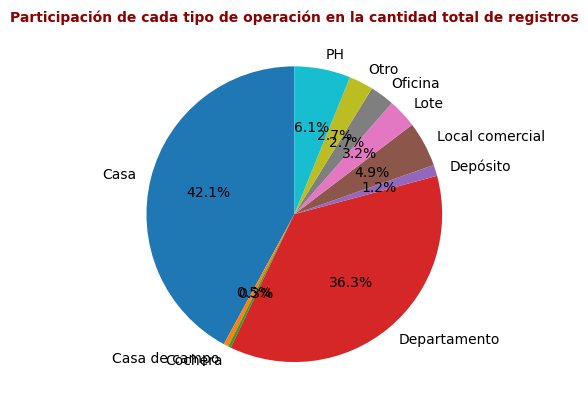

In [33]:
# Hago el Gráfico N° 1

aux1_df = prop_part_bsas_final_gdf.groupby(by="property_type").count().reset_index()
aux1_df["registros"] = aux1_df["price"]
aux1_df = aux1_df[["property_type", "registros"]]
print(aux1_df)

x = aux1_df["registros"]
y = aux1_df["property_type"]

plt.pie(x, labels=y, autopct="%.1f%%", startangle=90)
plt.title("Participación de cada tipo de operación en la cantidad total de registros", color="darkred", size=10, weight="bold")
plt.show() # El 42.1% de los registros son de casas

  currency  registros
0      ARS      24380
1      USD     112332


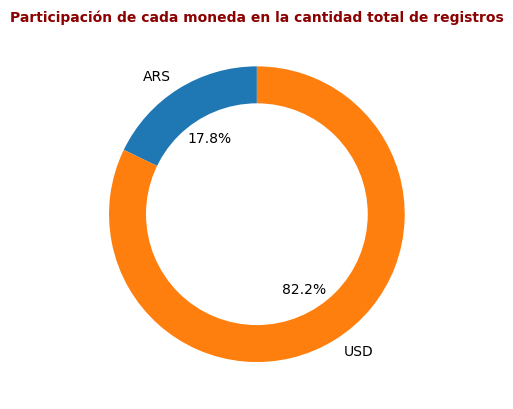

In [34]:
# Hago el Gráfico N° 2

aux2_df = prop_part_bsas_final_gdf.groupby(by="currency").count().reset_index()
aux2_df["registros"] = aux2_df["price"]
aux2_df = aux2_df[["currency", "registros"]]
print(aux2_df)

x = aux2_df["registros"]
y = aux2_df["currency"]

plt.pie(x, labels=y, autopct="%.1f%%", startangle=90)
plt.title("Participación de cada moneda en la cantidad total de registros", color="darkred", size=10, weight="bold")
circle = plt.Circle(xy=(0,0), radius=.75, facecolor="white")
plt.gca().add_artist(circle)
plt.show() # El 82.2% de los registros son en USD